In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC                          
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,          
    cross_val_score
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    roc_auc_score,
    roc_curve
)

df = pd.read_csv("f1_clean.csv")

FEATURES = ['grid', 'laps', 'points', 'fastestLapSpeed']
df = df.dropna(subset=FEATURES).reset_index(drop=True)

X = df[FEATURES].values
y = df['podium'].values

print(f"Dataset: {X.shape}")
print(f"Class balance — No podium: {(y==0).sum()}  Podium: {(y==1).sum()}")


Dataset: (5302, 4)
Class balance — No podium: 4393  Podium: 909


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,     
    stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)     

print(f"Train: {X_train_s.shape}  Test: {X_test_s.shape}")
print(f"Train podium rate: {y_train.mean()*100:.1f}%")
print(f"Test  podium rate: {y_test.mean()*100:.1f}%")


Train: (4241, 4)  Test: (1061, 4)
Train podium rate: 17.1%
Test  podium rate: 17.2%


In [3]:
print("Kernels we will compare: linear, rbf")
print()
print("Parameters to tune:")
print("  C     : regularisation (penalty for misclassification)")
print("          small C → wider margin, more errors allowed (underfits)")
print("          large C → narrow margin, fewer errors (can overfit)")
print()
print("  gamma : RBF kernel width (rbf only)")
print("          small gamma → smooth boundary (underfits)")
print("          large gamma → wiggly boundary (overfits)")


Kernels we will compare: linear, rbf

Parameters to tune:
  C     : regularisation (penalty for misclassification)
          small C → wider margin, more errors allowed (underfits)
          large C → narrow margin, fewer errors (can overfit)

  gamma : RBF kernel width (rbf only)
          small gamma → smooth boundary (underfits)
          large gamma → wiggly boundary (overfits)


In [4]:
for kernel in ['linear', 'rbf']:
    svm = SVC(
        kernel=kernel,
        C=1.0,                      
        class_weight='balanced',    
        probability=True,           
        random_state=42
    )
    scores = cross_val_score(svm, X_train_s, y_train, cv=5, scoring='roc_auc')
    print(f"Kernel={kernel:<8} | CV AUC = {scores.mean():.3f} ± {scores.std():.3f}")

print()
print("The kernel with higher CV AUC gets the full grid search treatment.")


Kernel=linear   | CV AUC = 1.000 ± 0.000
Kernel=rbf      | CV AUC = 1.000 ± 0.000

The kernel with higher CV AUC gets the full grid search treatment.


In [5]:
param_grid = {
    'C'    : [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1]
}

svm_rbf = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=True,
    random_state=42
)

grid_search = GridSearchCV(
    svm_rbf,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_s, y_train)

print(f"\nBest parameters : {grid_search.best_params_}")
print(f"Best CV AUC     : {grid_search.best_score_:.3f}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters : {'C': 100, 'gamma': 'scale'}
Best CV AUC     : 1.000


In [6]:
best_svm = grid_search.best_estimator_

y_pred = best_svm.predict(X_test_s)

y_prob = best_svm.predict_proba(X_test_s)[:, 1]

print(f"Best SVM: C={grid_search.best_params_['C']}, "
      f"gamma={grid_search.best_params_['gamma']}")
print(f"Accuracy : {accuracy_score(y_test, y_pred)*100:.1f}%")
print(f"AUC Score: {roc_auc_score(y_test, y_prob):.3f}")
print()
print("=== Classification Report ===")
print(classification_report(y_test, y_pred,
                             target_names=['No podium', 'Podium']))


Best SVM: C=100, gamma=scale
Accuracy : 99.9%
AUC Score: 1.000

=== Classification Report ===
              precision    recall  f1-score   support

   No podium       1.00      1.00      1.00       879
      Podium       0.99      1.00      1.00       182

    accuracy                           1.00      1061
   macro avg       1.00      1.00      1.00      1061
weighted avg       1.00      1.00      1.00      1061



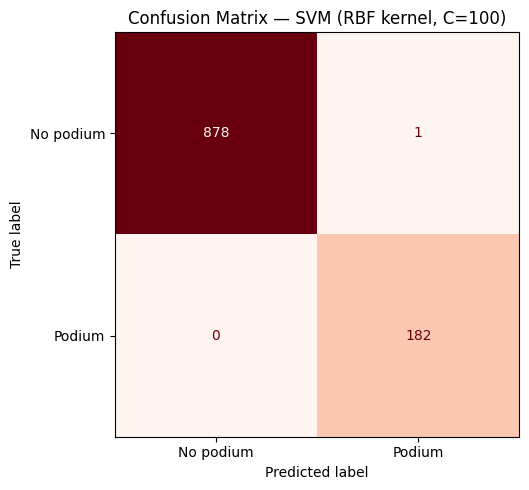

True Negatives  (TN): 878  — correctly predicted NO podium
False Positives (FP): 1  — predicted podium, was wrong
False Negatives (FN): 0  — missed actual podium finishes
True Positives  (TP): 182  — correctly predicted podium


In [7]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No podium', 'Podium'])
disp.plot(ax=ax, cmap='Reds', colorbar=False)
ax.set_title(f"Confusion Matrix — SVM (RBF kernel, "
             f"C={grid_search.best_params_['C']})")
plt.tight_layout()
plt.savefig("svm_confusion.png", dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (TN): {tn}  — correctly predicted NO podium")
print(f"False Positives (FP): {fp}  — predicted podium, was wrong")
print(f"False Negatives (FN): {fn}  — missed actual podium finishes")
print(f"True Positives  (TP): {tp}  — correctly predicted podium")


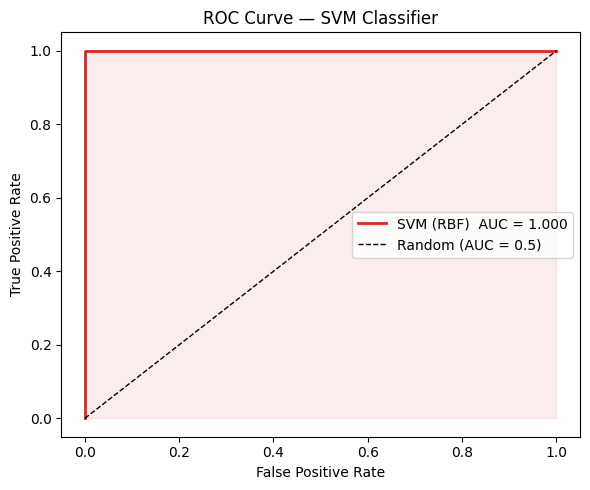

SVM AUC: 1.000


In [8]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#DC2626', linewidth=2,
        label=f'SVM (RBF)  AUC = {auc:.3f}')
ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.08, color='#DC2626')
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — SVM Classifier")
ax.legend()
plt.tight_layout()
plt.savefig("svm_roc.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"SVM AUC: {auc:.3f}")


In [9]:
n_sv = best_svm.n_support_
total_sv = sum(n_sv)
pct_sv = total_sv / len(X_train_s) * 100

print(f"Total training samples : {len(X_train_s)}")
print(f"Support vectors found  : {total_sv} ({pct_sv:.1f}% of training data)")
print(f"  Class 0 (no podium)  : {n_sv[0]} support vectors")
print(f"  Class 1 (podium)     : {n_sv[1]} support vectors")
print()
print("Interpretation:")
print("  A lower % of SVs = cleaner separation (margin is clearer)")
print("  A higher % of SVs = classes overlap, boundary is less certain")
print()
print("Key SVM property: only these support vectors matter.")

Total training samples : 4241
Support vectors found  : 59 (1.4% of training data)
  Class 0 (no podium)  : 22 support vectors
  Class 1 (podium)     : 37 support vectors

Interpretation:
  A lower % of SVs = cleaner separation (margin is clearer)
  A higher % of SVs = classes overlap, boundary is less certain

Key SVM property: only these support vectors matter.


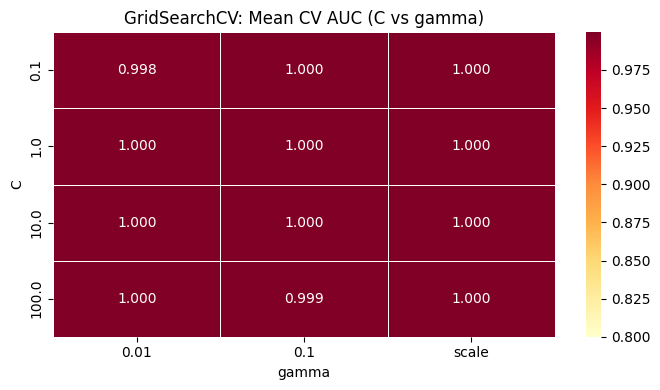

Saved: svm_gridsearch.png

Brightest cell = best hyperparameter combination.
If the best is at the edge of the grid, the grid should be extended.


In [10]:
import pandas as pd

results = pd.DataFrame(grid_search.cv_results_)

pivot = results.pivot_table(
    values='mean_test_score',
    index='param_C',
    columns='param_gamma'
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, vmin=0.8)
ax.set_title("GridSearchCV: Mean CV AUC (C vs gamma)")
ax.set_xlabel("gamma")
ax.set_ylabel("C")
plt.tight_layout()
plt.savefig("svm_gridsearch.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: svm_gridsearch.png")
print()
print("Brightest cell = best hyperparameter combination.")
print("If the best is at the edge of the grid, the grid should be extended.")


In [11]:
np.save("svm_y_prob.npy", y_prob)
np.save("y_test.npy", y_test)

svm_auc = roc_auc_score(y_test, y_prob)
svm_acc = accuracy_score(y_test, y_pred)

print("Saved: svm_y_prob.npy")
print("Saved: y_test.npy")
print()
print("=== Step 6 Summary ===")
print(f"Model         : SVM with RBF kernel")
print(f"Best C        : {grid_search.best_params_['C']}")
print(f"Best gamma    : {grid_search.best_params_['gamma']}")
print(f"Accuracy      : {svm_acc*100:.1f}%")
print(f"AUC Score     : {svm_auc:.3f}")
print()
print("Key SVM concepts to remember for the exam:")
print("  • Maximises the margin between classes")
print("  • Only support vectors define the boundary")
print("  • Kernel trick handles non-linear separation")
print("  • C controls the bias-variance tradeoff")
print("  • class_weight='balanced' handles imbalanced classes")

Saved: svm_y_prob.npy
Saved: y_test.npy

=== Step 6 Summary ===
Model         : SVM with RBF kernel
Best C        : 100
Best gamma    : scale
Accuracy      : 99.9%
AUC Score     : 1.000

Key SVM concepts to remember for the exam:
  • Maximises the margin between classes
  • Only support vectors define the boundary
  • Kernel trick handles non-linear separation
  • C controls the bias-variance tradeoff
  • class_weight='balanced' handles imbalanced classes
